In [1]:
#Klasyfikacja wieloklasowa (multi-class) - Wine Dataset

from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

import optuna

In [2]:
wine = load_wine()
wine.data.shape



(178, 13)

In [3]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target # etykiety klas
df[0:5]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
X = df.iloc[:,0:13]
y = df["target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)



In [6]:
all_methods = [ LogisticRegression(max_iter=5000), LDA(), KNeighborsClassifier(n_neighbors=1) ]

for i, method in enumerate(all_methods):
    model = method.fit(X_train, Y_train)
    res = model.predict(X_test)
    print(f"The accuracy for {method} is: {accuracy_score(Y_test, res)}")


# sample_weight w metodzie fit nadaje rozne wagi poszczegolnym probkom podczas treningu modelu
# sample_weight stosujemy, gdy klasy sa niezbalansowane, np. 10:90
# kilka innych zastosowan

The accuracy for LogisticRegression(max_iter=5000) is: 0.9629629629629629
The accuracy for LinearDiscriminantAnalysis() is: 0.9814814814814815
The accuracy for KNeighborsClassifier(n_neighbors=1) is: 0.7037037037037037


In [7]:
#2 
#Użyj 5-krotnej walidacji krzyżowej i stratyfikowanego podziału na foldy
# czyli podziel zbior danych na 5 foldow (rownych czesci), gdzie ostatni fold jest przeznaczony na dane walidacyjne
# do oceny modelu bierzemy srednia z wszystkich wytrenowanych foldow

# stratyfikowany podzial na klasy, czyli kazdy z foldow bedzie mial podobna proporcje klas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    max_iter = trial.suggest_int('max_iter', 100, 1000)
    
    clf = LogisticRegression(C=C, solver="liblinear", max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(clf, X_train, Y_train, cv=cv, scoring='accuracy').mean()
    return score

In [9]:
lr_study = optuna.create_study(direction="maximize")
lr_study.optimize(objective_lr, n_trials=10)

[I 2025-11-04 11:56:40,582] A new study created in memory with name: no-name-f27005d0-92e7-44b4-805b-14d9f04a70a9
[I 2025-11-04 11:56:40,635] Trial 0 finished with value: 0.9436666666666665 and parameters: {'C': 0.11823516812745735, 'solver': 'saga', 'max_iter': 771}. Best is trial 0 with value: 0.9436666666666665.
[I 2025-11-04 11:56:40,684] Trial 1 finished with value: 0.9436666666666665 and parameters: {'C': 0.9149131006969131, 'solver': 'liblinear', 'max_iter': 397}. Best is trial 0 with value: 0.9436666666666665.
[I 2025-11-04 11:56:40,724] Trial 2 finished with value: 0.9356666666666665 and parameters: {'C': 0.5680326478153349, 'solver': 'liblinear', 'max_iter': 872}. Best is trial 0 with value: 0.9436666666666665.
[I 2025-11-04 11:56:40,782] Trial 3 finished with value: 0.9113333333333333 and parameters: {'C': 0.03573681556724624, 'solver': 'liblinear', 'max_iter': 893}. Best is trial 0 with value: 0.9436666666666665.
[I 2025-11-04 11:56:40,824] Trial 4 finished with value: 0.91

In [10]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric))
    ])

    score = cross_val_score(clf, X_train, Y_train, cv=cv, scoring='accuracy').mean()
    return score


In [11]:
knn_study = optuna.create_study(direction="maximize")
knn_study.optimize(objective_knn, n_trials=10)

[I 2025-11-04 11:56:41,232] A new study created in memory with name: no-name-57513f1d-2330-4696-852d-1342cdce770d
[I 2025-11-04 11:56:41,323] Trial 0 finished with value: 0.992 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:41,386] Trial 1 finished with value: 0.96 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:41,460] Trial 2 finished with value: 0.992 and parameters: {'n_neighbors': 6, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:41,535] Trial 3 finished with value: 0.968 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:41,606] Trial 4 finished with value: 0.976 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with v

In [12]:
def objective_lda(trial):
    solver = trial.suggest_categorical('solver', ['svd', 'lsqr', 'eigen'])

    if solver in ['lsqr', 'eigen']:
        shrinkage = trial.suggest_float('shrinkage', 0.0, 1.0)
    else:
        shrinkage = None

    clf = LDA(solver=solver, shrinkage=shrinkage)

    score = cross_val_score(clf, X_train, Y_train, cv=cv, scoring='accuracy').mean()
    return score


In [13]:
lda_study = optuna.create_study(direction="maximize")
lda_study.optimize(objective_lda, n_trials=10)


[I 2025-11-04 11:56:41,981] A new study created in memory with name: no-name-e78c7a0f-c387-48e7-a69d-2f81c1081701
[I 2025-11-04 11:56:42,030] Trial 0 finished with value: 0.992 and parameters: {'solver': 'svd'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:42,119] Trial 1 finished with value: 0.702 and parameters: {'solver': 'eigen', 'shrinkage': 0.1108553738196918}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:42,168] Trial 2 finished with value: 0.992 and parameters: {'solver': 'svd'}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:42,214] Trial 3 finished with value: 0.686 and parameters: {'solver': 'eigen', 'shrinkage': 0.13219771789746315}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:42,261] Trial 4 finished with value: 0.7026666666666668 and parameters: {'solver': 'eigen', 'shrinkage': 0.7424941267220699}. Best is trial 0 with value: 0.992.
[I 2025-11-04 11:56:42,311] Trial 5 finished with value: 0.7106666666666668 and parameters: {'solver':

In [14]:
best_lr = lr_study.best_params
best_knn = knn_study.best_params
best_lda = lda_study.best_params
print("Best LogisticReg", best_lr)
print("Best KNN", best_knn)
print("Best Lda", best_lda)

Best LogisticReg {'C': 13.862847022026267, 'solver': 'liblinear', 'max_iter': 908}
Best KNN {'n_neighbors': 5, 'weights': 'distance', 'metric': 'manhattan'}
Best Lda {'solver': 'svd'}


In [15]:
clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=best_lr['C'],
        solver=best_lr['solver'],
        max_iter=best_lr['max_iter'],
        random_state=42
    ))
])

clf_lr.fit(X_train, Y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=13.862847022026267, max_iter=908,
                                    random_state=42, solver='liblinear'))])

In [16]:
y_pred_lr = clf_lr.predict(X_test) # predykcja etykiet
y_pred_lr_proba = clf_lr.predict_proba(X_test) # predykcja prawdopodobienstw
# Predict_proba wykorzystujemy do narysowania krzywej ROC, AUC
print(accuracy_score(y_pred_lr, Y_test))


0.9814814814814815


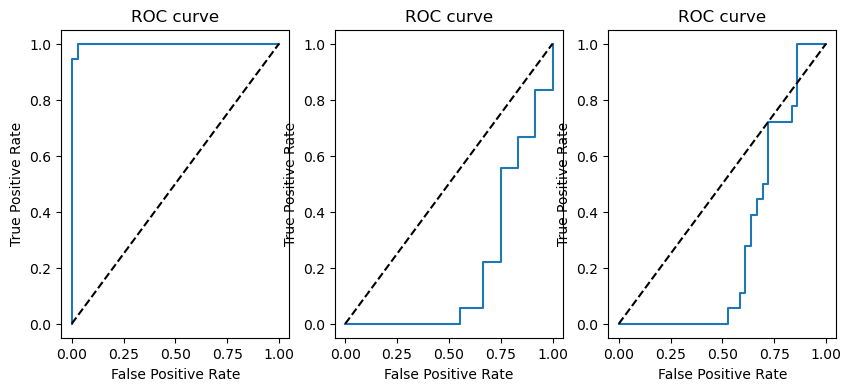

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10,4))
for i in range(0,3):
    
    y_pred_lr_proba_cl0 = y_pred_lr_proba[:,i]
    fpr, tpr, thresholds = roc_curve((Y_test == 0).astype(int), y_pred_lr_proba_cl0)
    auc_score = roc_auc_score((Y_test == 0).astype(int), y_pred_lr_proba_cl0)
    
    ax[i].plot(fpr, tpr, label=f'ROC class 0 (AUC={auc_score:.2f})')
    ax[i].plot([0,1], [0,1], 'k--')
    ax[i].set_xlabel('False Positive Rate')
    ax[i].set_ylabel('True Positive Rate')
    ax[i].set_title('ROC curve')

In [18]:
clf_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_knn['n_neighbors'],
        weights=best_knn['weights'],
        metric=best_knn['metric']
    ))
])

clf_knn.fit(X_train, Y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', weights='distance'))])

0.9814814814814815


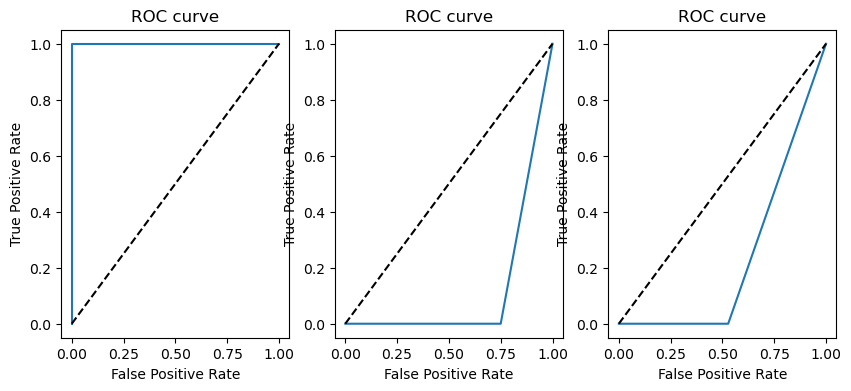

In [19]:
y_pred_knn = clf_knn.predict(X_test) # predykcja etykiet
y_pred_knn_proba = clf_knn.predict_proba(X_test) # predykcja prawdopodobienstw
# Predict_proba wykorzystujemy do narysowania krzywej ROC, AUC
print(accuracy_score(y_pred_knn, Y_test))

fig, ax = plt.subplots(1, 3, figsize=(10,4) )

for i in range(0,3):
    y_pred_knn_proba_cl0 = y_pred_knn_proba[:,i]
    fpr, tpr, thresholds = roc_curve((Y_test == 0).astype(int), y_pred_knn_proba_cl0)
    auc_score = roc_auc_score((Y_test == 0).astype(int), y_pred_knn_proba_cl0)
    
    ax[i].plot(fpr, tpr, label=f'ROC class 0 (AUC={auc_score:.2f})')
    ax[i].plot([0,1], [0,1], 'k--')
    ax[i].set_xlabel('False Positive Rate')
    ax[i].set_ylabel('True Positive Rate')
    ax[i].set_title('ROC curve')

In [20]:
y_pred_knn = clf_knn.predict(X_test)
accuracy_score(y_pred_knn, Y_test)

0.9814814814814815

In [21]:
solver = best_lda['solver']
shrinkage = best_lda.get('shrinkage', None) 

clf_lda = LDA(solver=solver, shrinkage=shrinkage)
clf_lda.fit(X_train, Y_train)
y_pred_lda = clf_lda.predict(X_test)
accuracy_score(Y_test, y_pred_lda)

0.9814814814814815

0.9814814814814815


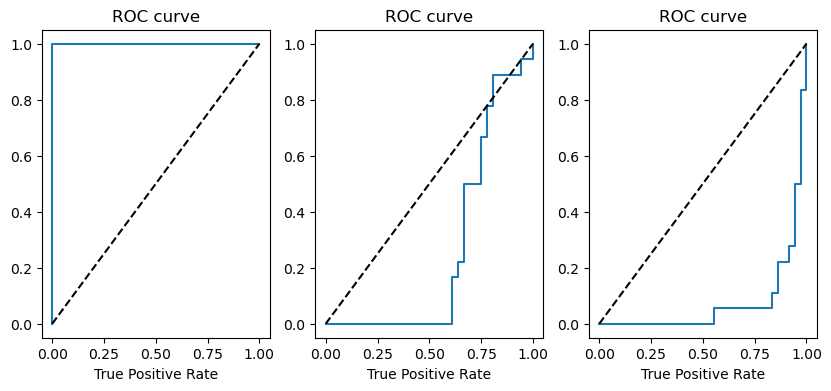

In [22]:
y_pred_lda = clf_lda.predict(X_test) # predykcja etykiet
y_pred_lda_proba = clf_lda.predict_proba(X_test) # predykcja prawdopodobienstw
# Predict_proba wykorzystujemy do narysowania krzywej ROC, AUC
print(accuracy_score(y_pred_lda, Y_test))

fig, ax = plt.subplots(1, 3, figsize=(10,4) )

for i in range(0,3):
    y_pred_lda_proba_cl0 = y_pred_lda_proba[:,i]
    fpr, tpr, thresholds = roc_curve((Y_test == 0).astype(int), y_pred_lda_proba_cl0)
    auc_score = roc_auc_score((Y_test == 0).astype(int), y_pred_lda_proba_cl0)
    
    ax[i].plot(fpr, tpr, label=f'ROC class 0 (AUC={auc_score:.2f})')
    ax[i].plot([0,1], [0,1], 'k--')
    ax[i].set_xlabel('False Positive Rate')
    ax[i].set_xlabel('True Positive Rate')
    ax[i].set_title('ROC curve')


# Widac krzywe ROC sa ewidentnie zle skalibrowane. Nie dokonalem wczesniej binaryzacji, a jest to potrzebne do dokladnego parametru modelu


In [23]:
classes = [0,1,2]

Y_train_bin = label_binarize(Y_train, classes=classes)
Y_test_bin  = label_binarize(Y_test, classes=classes)

In [24]:
def evaluate_classifier(clf, X_train, Y_train, X_test, Y_test, model_name="Model"):
    # --- Predykcje ---
    y_train_pred = clf.predict(X_train)
    y_test_pred  = clf.predict(X_test)
    
    y_train_proba = clf.predict_proba(X_train)
    y_test_proba  = clf.predict_proba(X_test)
    
    # --- Dokładność ---
    acc_train = accuracy_score(Y_train, y_train_pred)
    acc_test  = accuracy_score(Y_test, y_test_pred)
    
    print(f"=== {model_name} ===")
    print(f"Accuracy - Train: {acc_train:.3f}, Test: {acc_test:.3f}\n")
    
    # --- Czułość / Recall ---
    recall_train_per_class = recall_score(Y_train, y_train_pred, average=None)
    recall_test_per_class  = recall_score(Y_test, y_test_pred, average=None)
    recall_train_macro = recall_score(Y_train, y_train_pred, average='macro')
    recall_test_macro  = recall_score(Y_test, y_test_pred, average='macro')
    
    print("Recall per class - Train:", recall_train_per_class)
    print("Recall per class - Test:", recall_test_per_class)
    print("Macro-averaged Recall - Train:", recall_train_macro)
    print("Macro-averaged Recall - Test:", recall_test_macro, "\n")
    
    # --- Specyficzność ---
    specificity_train = []
    specificity_test = []
    for i in range(len(classes)):
        cm_train = confusion_matrix(Y_train, y_train_pred)
        cm_test  = confusion_matrix(Y_test, y_test_pred)
        tn_train = cm_train.sum() - (cm_train[i,:].sum() + cm_train[:,i].sum() - cm_train[i,i])
        fp_train = cm_train[:,i].sum() - cm_train[i,i]
        specificity_train.append(tn_train / (tn_train + fp_train))
        
        tn_test = cm_test.sum() - (cm_test[i,:].sum() + cm_test[:,i].sum() - cm_test[i,i])
        fp_test = cm_test[:,i].sum() - cm_test[i,i]
        specificity_test.append(tn_test / (tn_test + fp_test))
    
    print("Specificity per class - Train:", np.round(specificity_train,3))
    print("Specificity per class - Test:", np.round(specificity_test,3))
    print("Macro-averaged Specificity - Train:", np.mean(specificity_train))
    print("Macro-averaged Specificity - Test:", np.mean(specificity_test), "\n")
    
    # --- ROC i AUC ---
    fpr_train, tpr_train, auc_train = {}, {}, {}
    fpr_test, tpr_test, auc_test = {}, {}, {}
    for i in range(len(classes)):
        fpr_train[i], tpr_train[i], _ = roc_curve(Y_train_bin[:,i], y_train_proba[:,i])
        auc_train[i] = roc_auc_score(Y_train_bin[:,i], y_train_proba[:,i])
        
        fpr_test[i], tpr_test[i], _ = roc_curve(Y_test_bin[:,i], y_test_proba[:,i])
        auc_test[i] = roc_auc_score(Y_test_bin[:,i], y_test_proba[:,i])
    
    auc_train_macro = np.mean(list(auc_train.values()))
    auc_test_macro  = np.mean(list(auc_test.values()))
    
    print("AUC per class - Train:", np.round(list(auc_train.values()),3))
    print("AUC per class - Test:", np.round(list(auc_test.values()),3))
    print("Macro-averaged AUC - Train:", np.round(auc_train_macro,3))
    print("Macro-averaged AUC - Test:", np.round(auc_test_macro,3), "\n")
    
    # --- Macierze pomyłek ---
    print("Confusion matrix - Train:\n", confusion_matrix(Y_train, y_train_pred))
    print("Confusion matrix - Test:\n", confusion_matrix(Y_test, y_test_pred))
    
    # --- Wykres ROC (Test) ---
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        plt.plot(fpr_test[i], tpr_test[i], label=f'Class {i} (AUC={auc_test[i]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name} (Test)')
    plt.legend()
    plt.show()


=== Logistic Regression ===
Accuracy - Train: 1.000, Test: 0.981

Recall per class - Train: [1. 1. 1.]
Recall per class - Test: [1.         0.95238095 1.        ]
Macro-averaged Recall - Train: 1.0
Macro-averaged Recall - Test: 0.9841269841269842 

Specificity per class - Train: [1. 1. 1.]
Specificity per class - Test: [0.972 1.    1.   ]
Macro-averaged Specificity - Train: 1.0
Macro-averaged Specificity - Test: 0.9907407407407408 

AUC per class - Train: [1. 1. 1.]
AUC per class - Test: [0.998 0.994 1.   ]
Macro-averaged AUC - Train: 1.0
Macro-averaged AUC - Test: 0.998 

Confusion matrix - Train:
 [[41  0  0]
 [ 0 50  0]
 [ 0  0 33]]
Confusion matrix - Test:
 [[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


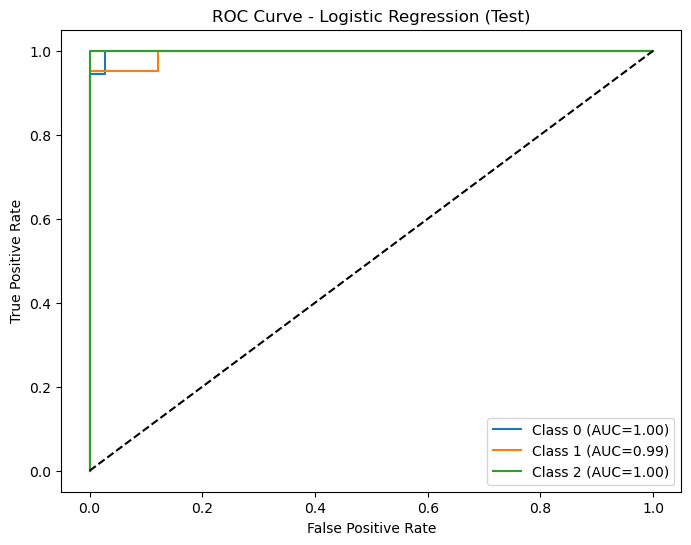

=== kNN ===
Accuracy - Train: 1.000, Test: 0.981

Recall per class - Train: [1. 1. 1.]
Recall per class - Test: [1.         0.95238095 1.        ]
Macro-averaged Recall - Train: 1.0
Macro-averaged Recall - Test: 0.9841269841269842 

Specificity per class - Train: [1. 1. 1.]
Specificity per class - Test: [1.    1.    0.974]
Macro-averaged Specificity - Train: 1.0
Macro-averaged Specificity - Test: 0.9914529914529915 

AUC per class - Train: [1. 1. 1.]
AUC per class - Test: [1. 1. 1.]
Macro-averaged AUC - Train: 1.0
Macro-averaged AUC - Test: 1.0 

Confusion matrix - Train:
 [[41  0  0]
 [ 0 50  0]
 [ 0  0 33]]
Confusion matrix - Test:
 [[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


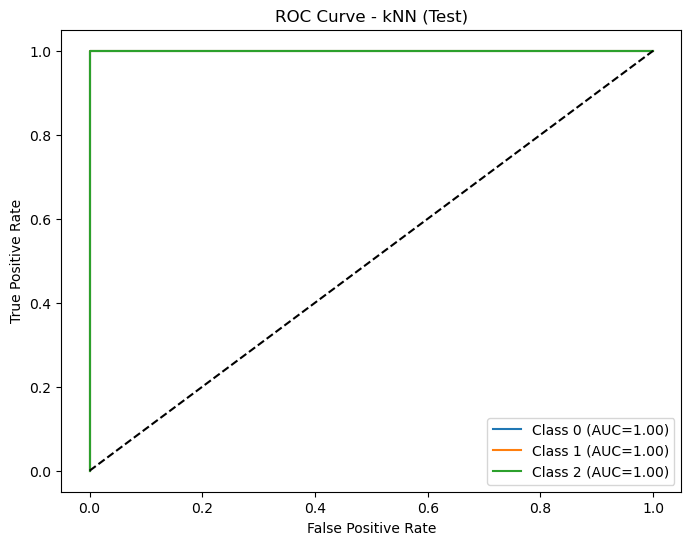

=== LDA ===
Accuracy - Train: 1.000, Test: 0.981

Recall per class - Train: [1. 1. 1.]
Recall per class - Test: [1.         0.95238095 1.        ]
Macro-averaged Recall - Train: 1.0
Macro-averaged Recall - Test: 0.9841269841269842 

Specificity per class - Train: [1. 1. 1.]
Specificity per class - Test: [0.972 1.    1.   ]
Macro-averaged Specificity - Train: 1.0
Macro-averaged Specificity - Test: 0.9907407407407408 

AUC per class - Train: [1. 1. 1.]
AUC per class - Test: [1. 1. 1.]
Macro-averaged AUC - Train: 1.0
Macro-averaged AUC - Test: 1.0 

Confusion matrix - Train:
 [[41  0  0]
 [ 0 50  0]
 [ 0  0 33]]
Confusion matrix - Test:
 [[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


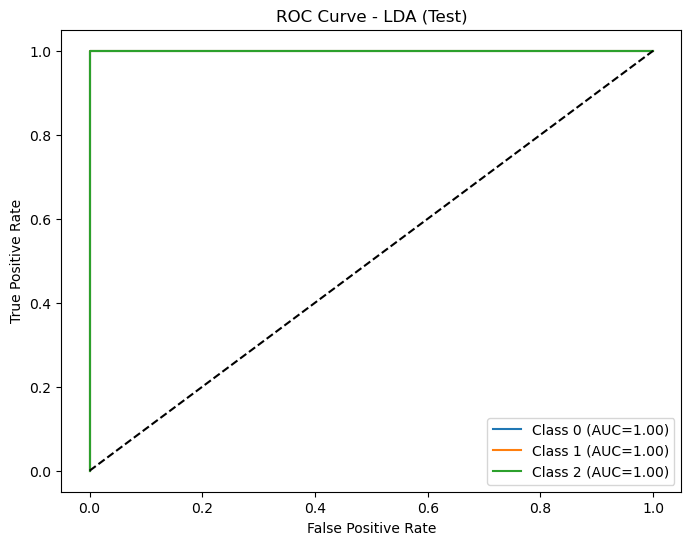

In [25]:
# Logistic Regression
evaluate_classifier(clf_lr, X_train, Y_train, X_test, Y_test, model_name="Logistic Regression")

# kNN
evaluate_classifier(clf_knn, X_train, Y_train, X_test, Y_test, model_name="kNN")

# LDA
evaluate_classifier(clf_lda, X_train, Y_train, X_test, Y_test, model_name="LDA")
